# 12 SPA 检验与模型综合

本 Notebook 实现清单最后一项：对第 09 项固定、已验收的 15 个 primary 模型预测，直接重算三类真实方差代理，以最低 RMSFE 模型为基准完成论文 Table 9 风格的 Hansen (2005) Superior Predictive Ability（SPA）检验，并进一步汇总模型类别、盘中/日频采样频率、FU 两个制度阶段与 RB 扩展结果。

这里不读取第 10 或第 11 项 Notebook 输出，不写正式 `silver`、`gold`、项目缓存或新的研究数据成果；唯一外部研究输入仍是 README 固定的第 09 项版本化预测成果。无前视敏感性模型不进入论文基线检验。


## 1. 在做什么，以及经济意义

DM–West 是逐对比较；当研究者从许多模型中挑出“最好”的一个时，单个显著结果可能只是反复尝试后的偶然发现。SPA 把全部竞争模型同时纳入同一个原假设：**基准模型不劣于任何竞争模型**。只有 p 值足够小，才能认为至少存在一个模型在控制数据挖掘后仍显著优于基准。

经济上，本项区分“样本 RMSFE 排名第一”和“在考虑整个模型集合后仍能排除其他模型更好”这两个问题。论文 Table 9 只检验最低 RMSFE 基准；为完成模型综合，本 Notebook 还让每个模型轮流作为候选基准。后者形成的是“SPA 未拒绝候选集合”，它不是正式 Model Confidence Set，未拒绝也不等于已经证明等价。


## 2. 论文公式、Table 9 对应和当前复现等级

对候选基准 \(b\) 和竞争模型 \(k\)，沿用论文损失方向：

\[
d_{k,t}=L_{b,t}-L_{k,t}.
\]

正值表示竞争模型损失更小。SPA 的复合原假设是

\[
H_0:\max_k E[d_{k,t}]\le 0,
\]

studentized 统计量为

\[
T^{SPA}=\max\left\{0,\max_k
\frac{\sqrt R\,\bar d_k}{\widehat\omega_k}\right\}.
\]

\(\widehat\omega_k^2\) 使用 Hansen 给出的 stationary-bootstrap 长期方差：令 \(q=1/\ell\)、\(\ell=\lfloor\sqrt R\rfloor\)，核权重为

\[
\kappa(R,j)=\left(1-\frac jR\right)(1-q)^j
+\frac jR(1-q)^{R-j}.
\]

bootstrap 样本分别用 lower、consistent、upper 三种重心函数。consistent 阈值按

\[
\bar d_k\ge -\sqrt{\frac{\widehat\omega_k^2}{R}
2\log\log R}
\]

判断模型是否参与重心；consistent p 值为主，lower/upper 同时展示。固定 10,000 次 stationary bootstrap、`studentized=True`、种子 `20260830`，同一 \(R\) 的所有比较复用同一组随机索引；若观察统计量为零，按 Hansen 的约定令 p 值为 1。

`arch.bootstrap.StationaryBootstrap` 只用于生成 Politis–Romano 随机索引；长期方差、标准化、重心与 p 值均在 Notebook 中按公式直接呈现。没有嵌套 bootstrap。

- 论文对应：2.3.3 节与 Table 9。
- Table 9：15 个“序列 × 代理”最低 RMSFE 基准，各与其余 14 个模型整体比较。
- 扩展综合：225 个“序列 × 代理 × 候选基准”SPA 检验，用于构造明确限定的未拒绝候选集合。
- 当前复现等级：**方法复现**，不声称复制论文 GTA 数值。

代码分为六步：①验收固定 Item 09；②从 silver 重算 OOS 三类代理；③构造 primary 损失和 RMSFE；④生成固定 stationary-bootstrap 索引并计算 studentized SPA；⑤汇总模型类别与采样频率；⑥随机种子、方差、p 值和边界门禁。


In [1]:
from __future__ import annotations

from datetime import date
import gc
import hashlib
import json
import pathlib
import re
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from arch.bootstrap import StationaryBootstrap

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from a00_03_notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

project_dir = (
    project_root
    / "01_project_collection"
    / "china_commodity_futures_intraday_volatility_forecasting_reproduction"
)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"研究项目目录: {project_dir}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
研究项目目录: E:\Latitude_Analytics_v2\01_project_collection\china_commodity_futures_intraday_volatility_forecasting_reproduction
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

本项直接参与读取的权威 silver 表仍是合约日历、品种日历和一分钟事实。读取前先展示表名、主键、分区顺序、字段、Arrow 类型及 nullable。


In [2]:
display_schema_metadata(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与固定成果身份

五个研究序列、OOS 日数、真实日盘、三个月交割合约、三类方差代理与 Item 09 run 身份全部沿用 README。SPA 只使用 `is_primary=True` 的 15 个模型。


In [3]:
exchange_code = "XSGE"
expected_day_sessions = 3
expected_day_minutes = 225
five_minute_interval = 5
expected_five_minute_slots = 45
expected_medrv_terms = expected_five_minute_slots - 2
zero_return_tolerance = 1e-12

medrv_consistency_constant = np.pi / (6 - 4 * np.sqrt(3) + np.pi)
medrv_finite_sample_multiplier = expected_five_minute_slots / expected_medrv_terms
medrv_total_multiplier = medrv_consistency_constant * medrv_finite_sample_multiplier

fixed_run_id = "eaf4757d3488c2b7"
fixed_run_fingerprint = (
    "eaf4757d3488c2b74f1e81fa558d8146"
    "cdee562836f7fd4084b32ac7ca6fdec6"
)
expected_artifact_contract_version = "item09-rolling-forecast-stream-v1"
expected_storage_layout = "flat-v2"
artifact_run_dir = project_dir / "data" / "item09" / fixed_run_id

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
for date_column in ["sample_start", "sample_end"]:
    sample_spec_df[date_column] = pd.to_datetime(sample_spec_df[date_column])

series_order = sample_spec_df["series_id"].tolist()
proxy_spec = [
    ("realized_variance", "RV_5min", "Panel A: 5-min realized variance"),
    ("median_based_variance", "MedRV", "Panel B: median-based variance"),
    ("range_based_variance", "Parkinson", "Panel C: range-based variance"),
]
proxy_order = [proxy_id for _, proxy_id, _ in proxy_spec]
proxy_panel_label = {proxy_id: label for _, proxy_id, label in proxy_spec}

display(sample_spec_df)
display(
    pd.DataFrame(
        {
            "parameter": [
                "fixed_run_id",
                "fixed_run_fingerprint",
                "artifact_contract_version",
                "storage_layout",
                "five_minute_slots",
                "MedRV terms",
                "MedRV total multiplier",
            ],
            "value": [
                fixed_run_id,
                fixed_run_fingerprint,
                expected_artifact_contract_version,
                expected_storage_layout,
                expected_five_minute_slots,
                expected_medrv_terms,
                medrv_total_multiplier,
            ],
        }
    )
)

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,parameter,value
0,fixed_run_id,eaf4757d3488c2b7
1,fixed_run_fingerprint,eaf4757d3488c2b74f1e81fa558d8146cdee562836f7fd4084b32ac7ca6fdec6
2,artifact_contract_version,item09-rolling-forecast-stream-v1
3,storage_layout,flat-v2
4,five_minute_slots,45
5,MedRV terms,43
6,MedRV total multiplier,1.485375


## 5. 固定 Item 09 成果的完整性验证与预测读取

逐项核对 README 固定 run、`_SUCCESS`、manifest、四张最终 Parquet 的 SHA-256、Arrow Schema 指纹、行数和 27 项上游门禁。任何不一致都停止，不改读 `LATEST`，不重算 Item 09。


In [4]:
def sha256_file(file_path):
    file_hasher = hashlib.sha256()
    with pathlib.Path(file_path).open("rb") as binary_stream:
        for file_chunk in iter(lambda: binary_stream.read(1024 * 1024), b""):
            file_hasher.update(file_chunk)
    return file_hasher.hexdigest()


readme_text = (project_dir / "README.md").read_text(encoding="utf-8")
fixed_run_match = re.search(
    r"当前固定且已完整验收.*?run_id.*?\*\*`([0-9a-f]{16})`\*\*",
    readme_text,
    flags=re.DOTALL,
)
assert fixed_run_match is not None
assert fixed_run_match.group(1) == fixed_run_id
assert f"**`{fixed_run_fingerprint}`**" in readme_text

success_path = artifact_run_dir / "_SUCCESS.json"
manifest_path = artifact_run_dir / "manifest.json"
assert success_path.is_file() and manifest_path.is_file(), artifact_run_dir

success_payload = json.loads(success_path.read_text(encoding="utf-8"))
manifest_payload = json.loads(manifest_path.read_text(encoding="utf-8"))
assert success_payload["artifact_contract_version"] == expected_artifact_contract_version
assert success_payload["storage_layout"] == expected_storage_layout
assert success_payload["run_id"] == fixed_run_id
assert success_payload["run_fingerprint"] == fixed_run_fingerprint
assert success_payload["manifest_sha256"] == sha256_file(manifest_path)
assert manifest_payload["status"] == "complete"
assert manifest_payload["artifact_contract_version"] == expected_artifact_contract_version
assert manifest_payload["storage_layout"] == expected_storage_layout
assert manifest_payload["run_id"] == fixed_run_id
assert manifest_payload["run_fingerprint"] == fixed_run_fingerprint
assert manifest_payload["expected_streams"] == 120
assert manifest_payload["expected_forecast_rows"] == 31_200
assert manifest_payload["expected_step_rows"] == 214_500

artifact_file_audit_rows = []
artifact_file_record_by_role = {}
for file_record in manifest_payload["consolidated_files"]:
    artifact_role = file_record["artifact_role"]
    artifact_file_record_by_role[artifact_role] = file_record
    artifact_file_path = artifact_run_dir / file_record["relative_path"]
    actual_schema = pq.read_schema(artifact_file_path).remove_metadata()
    actual_schema_fingerprint = hashlib.sha256(
        actual_schema.serialize().to_pybytes()
    ).hexdigest()
    actual_metadata = pq.read_metadata(artifact_file_path)
    file_passed = (
        artifact_file_path.is_file()
        and artifact_file_path.stat().st_size == file_record["bytes"]
        and sha256_file(artifact_file_path) == file_record["sha256"]
        and actual_schema.names == file_record["columns"]
        and actual_schema_fingerprint == file_record["schema_fingerprint"]
        and actual_metadata.num_rows == file_record["rows"]
    )
    artifact_file_audit_rows.append(
        {
            "artifact_role": artifact_role,
            "relative_path": file_record["relative_path"],
            "rows": actual_metadata.num_rows,
            "bytes": artifact_file_path.stat().st_size,
            "integrity_passed": file_passed,
        }
    )
assert set(artifact_file_record_by_role) == {
    "forecast_panel",
    "forecast_steps",
    "stream_summary",
    "validation_gates",
}
artifact_file_audit_df = pd.DataFrame(artifact_file_audit_rows)
assert artifact_file_audit_df["integrity_passed"].all()

validation_gate_path = (
    artifact_run_dir
    / artifact_file_record_by_role["validation_gates"]["relative_path"]
)
upstream_validation_df = pq.read_table(validation_gate_path).to_pandas()
assert len(upstream_validation_df) == manifest_payload["validation_gate_count"] == 27
assert upstream_validation_df["passed"].all()

forecast_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "model_information_end",
    "seasonality_information_end",
    "forecast_variance",
    "fit_success",
    "target_contract_code",
    "underlying_code",
    "target_is_roll_day",
    "origin_contract_code",
]
forecast_panel_path = (
    artifact_run_dir
    / artifact_file_record_by_role["forecast_panel"]["relative_path"]
)
forecast_panel_df = pq.read_table(
    forecast_panel_path,
    columns=forecast_columns,
).to_pandas()
for date_column in [
    "forecast_origin_date",
    "forecast_date",
    "model_information_end",
    "seasonality_information_end",
]:
    forecast_panel_df[date_column] = pd.to_datetime(forecast_panel_df[date_column])
forecast_panel_df = forecast_panel_df.sort_values(
    ["series_id", "forecast_date", "model_id"],
    ignore_index=True,
)

assert len(forecast_panel_df) == 31_200
assert not forecast_panel_df.duplicated(
    ["series_id", "forecast_date", "model_id"]
).any()
assert forecast_panel_df["fit_success"].all()
assert np.isfinite(forecast_panel_df["forecast_variance"]).all()
assert forecast_panel_df["forecast_variance"].gt(0).all()

display(artifact_file_audit_df)
display(
    forecast_panel_df.groupby(
        ["series_id", "is_primary"], observed=True
    ).agg(
        forecast_rows=("model_id", "size"),
        model_count=("model_id", "nunique"),
        target_days=("forecast_date", "nunique"),
        first_target=("forecast_date", "min"),
        last_target=("forecast_date", "max"),
    ).reset_index()
)

,artifact_role,relative_path,rows,bytes,integrity_passed
0,forecast_panel,forecast_panel.parquet,31200,5423310,True
1,forecast_steps,forecast_steps.parquet,214500,4235533,True
2,stream_summary,stream_summary.parquet,120,8701,True
3,validation_gates,validation_gates.parquet,27,4415,True


,series_id,is_primary,forecast_rows,model_count,target_days,first_target,last_target
0,AL,False,2700,9,300,2025-06-10,2026-08-28
1,AL,True,4500,15,300,2025-06-10,2026-08-28
2,CU,False,2700,9,300,2025-06-10,2026-08-28
3,CU,True,4500,15,300,2025-06-10,2026-08-28
4,FU_legacy,False,1800,9,200,2010-12-10,2011-09-30
5,FU_legacy,True,3000,15,200,2010-12-10,2011-09-30
6,FU_relaunched,False,1800,9,200,2025-11-05,2026-08-28
7,FU_relaunched,True,3000,15,200,2025-11-05,2026-08-28
8,RB,False,2700,9,300,2025-06-10,2026-08-28
9,RB,True,4500,15,300,2025-06-10,2026-08-28


## 6. 正式 silver 数据集与样本外固定三个月合约

直接按权威 Schema 打开三个 silver Dataset，只读取 1,300 个目标日。合约代码交割年月必须等于交易月后第三个月；FU 两段分别处理；仅保留真实日盘 Session。


In [5]:
source_schema_by_role = {
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
1,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
2,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [6]:
target_consistency_df = (
    forecast_panel_df.groupby(
        ["series_id", "forecast_date"], observed=True, sort=True
    )
    .agg(
        target_contract_count=("target_contract_code", "nunique"),
        underlying_count=("underlying_code", "nunique"),
        roll_flag_count=("target_is_roll_day", "nunique"),
        origin_contract_count=("origin_contract_code", "nunique"),
    )
    .reset_index()
)
assert target_consistency_df[
    [
        "target_contract_count",
        "underlying_count",
        "roll_flag_count",
        "origin_contract_count",
    ]
].eq(1).all().all()

target_day_df = (
    forecast_panel_df.groupby(
        ["series_id", "forecast_date"], observed=True, sort=True
    )
    .agg(
        target_contract_code=("target_contract_code", "first"),
        underlying_code=("underlying_code", "first"),
        target_is_roll_day=("target_is_roll_day", "first"),
        origin_contract_code=("origin_contract_code", "first"),
    )
    .reset_index()
    .merge(
        sample_spec_df,
        on=["series_id", "underlying_code"],
        how="left",
        validate="many_to_one",
    )
)
assert len(target_day_df) == int(sample_spec_df["oos_days"].sum()) == 1_300
assert target_day_df["research_role"].notna().all()

target_contract_parts = target_day_df["target_contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
assert target_contract_parts.notna().all().all()
target_day_df["code_underlying"] = target_contract_parts[0]
target_day_df["delivery_year"] = 2000 + target_contract_parts[1].str[:2].astype("int16")
target_day_df["delivery_month"] = target_contract_parts[1].str[2:].astype("int8")
target_day_df["code_exchange"] = target_contract_parts[2]
target_delivery_period = pd.PeriodIndex(target_day_df["forecast_date"], freq="M") + 3
assert target_day_df["code_underlying"].eq(target_day_df["underlying_code"]).all()
assert target_day_df["code_exchange"].eq(exchange_code).all()
assert target_day_df["delivery_year"].eq(target_delivery_period.year).all()
assert target_day_df["delivery_month"].eq(target_delivery_period.month).all()

oos_date_audit_df = (
    target_day_df.groupby("series_id", observed=True)
    .agg(
        oos_days=("forecast_date", "size"),
        first_oos_date=("forecast_date", "min"),
        last_oos_date=("forecast_date", "max"),
        target_contracts=("target_contract_code", "nunique"),
        roll_days=("target_is_roll_day", "sum"),
    )
    .reset_index()
    .merge(
        sample_spec_df[["series_id", "sample_end", "oos_days"]].rename(
            columns={"oos_days": "expected_oos_days"}
        ),
        on="series_id",
        validate="one_to_one",
    )
)
assert oos_date_audit_df["oos_days"].eq(oos_date_audit_df["expected_oos_days"]).all()
assert oos_date_audit_df["last_oos_date"].eq(oos_date_audit_df["sample_end"]).all()

oos_filter = None
for sample_spec in sample_spec_df.itertuples(index=False):
    series_target_dates = target_day_df.loc[
        target_day_df["series_id"].eq(sample_spec.series_id),
        "forecast_date",
    ]
    series_filter = (
        (ds.field("underlying_code") == sample_spec.underlying_code)
        & (ds.field("year") >= int(series_target_dates.min().year))
        & (ds.field("year") <= int(series_target_dates.max().year))
        & (
            ds.field("trading_date")
            >= pa.scalar(series_target_dates.min().date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(series_target_dates.max().date(), type=pa.date32())
        )
    )
    oos_filter = series_filter if oos_filter is None else (oos_filter | series_filter)

contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in contract_columns]
)
contract_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=(ds.field("exchange_code") == exchange_code)
    & (ds.field("is_night_session") == False)
    & oos_filter,
)
validated_contract_table = validate_arrow_table(
    contract_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)
assert not contract_calendar_df["is_night_session"].any()

target_contract_key_df = target_day_df.rename(
    columns={"forecast_date": "trading_date"}
)[
    [
        "series_id",
        "trading_date",
        "target_contract_code",
        "underlying_code",
        "target_is_roll_day",
    ]
].rename(columns={"target_contract_code": "contract_code"})
selected_target_session_df = target_contract_key_df.merge(
    contract_calendar_df,
    on=["contract_code", "underlying_code", "trading_date"],
    how="left",
    validate="one_to_many",
)
assert selected_target_session_df["session_number"].notna().all()

target_session_audit_df = (
    selected_target_session_df.groupby(
        ["series_id", "trading_date", "contract_code"], observed=True
    )
    .agg(
        session_count=("session_number", "nunique"),
        minute_count=("minute_count", "sum"),
        night_sessions=("is_night_session", "sum"),
    )
    .reset_index()
)
assert len(target_session_audit_df) == 1_300
assert target_session_audit_df["session_count"].eq(expected_day_sessions).all()
assert target_session_audit_df["minute_count"].eq(expected_day_minutes).all()
assert target_session_audit_df["night_sessions"].eq(0).all()

display(oos_date_audit_df)
display(target_session_audit_df.groupby("series_id", observed=True).agg(
    contract_days=("trading_date", "size"),
    sessions=("session_count", "sum"),
    expected_minutes=("minute_count", "sum"),
).reset_index())

,series_id,oos_days,first_oos_date,last_oos_date,target_contracts,roll_days,sample_end,expected_oos_days
0,AL,300,2025-06-10,2026-08-28,15,14,2026-08-28,300
1,CU,300,2025-06-10,2026-08-28,15,14,2026-08-28,300
2,FU_legacy,200,2010-12-10,2011-09-30,10,9,2011-09-30,200
3,FU_relaunched,200,2025-11-05,2026-08-28,10,9,2026-08-28,200
4,RB,300,2025-06-10,2026-08-28,15,14,2026-08-28,300


,series_id,contract_days,sessions,expected_minutes
0,AL,300,900,67500
1,CU,300,900,67500
2,FU_legacy,200,600,45000
3,FU_relaunched,200,600,45000
4,RB,300,900,67500


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
bar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=(ds.field("exchange_code") == exchange_code)
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
    & oos_filter,
)
validated_bar_table = validate_arrow_table(bar_table, bar_projection_schema)
bar_calendar_df = arrow_to_pandas(validated_bar_table, bar_projection_schema)
bar_calendar_df["trading_date"] = pd.to_datetime(bar_calendar_df["trading_date"])

session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df.merge(
    bar_calendar_df,
    on=session_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)
assert selected_bar_session_df["eligible_session"].all()

bar_day_audit_df = (
    selected_bar_session_df.groupby(
        ["series_id", "trading_date", "contract_code"], observed=True
    )
    .agg(
        session_rows=("session_number", "size"),
        eligible_sessions=("eligible_session", "sum"),
        expected_minutes=("expected_bar_count", "sum"),
        actual_minutes=("actual_bar_count", "sum"),
        missing_minutes=("missing_bar_count", "sum"),
    )
    .reset_index()
)
assert bar_day_audit_df["session_rows"].eq(expected_day_sessions).all()
assert bar_day_audit_df["eligible_sessions"].eq(expected_day_sessions).all()
assert bar_day_audit_df["expected_minutes"].eq(expected_day_minutes).all()
assert bar_day_audit_df["actual_minutes"].eq(expected_day_minutes).all()
assert bar_day_audit_df["missing_minutes"].eq(0).all()

complete_session_keys_df = selected_bar_session_df.loc[
    selected_bar_session_df["eligible_session"],
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "target_is_roll_day",
        "expected_bar_count",
    ],
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

display(
    bar_day_audit_df.groupby("series_id", observed=True).agg(
        contract_days=("trading_date", "size"),
        eligible_sessions=("eligible_sessions", "sum"),
        expected_minutes=("expected_minutes", "sum"),
        actual_minutes=("actual_minutes", "sum"),
    ).reset_index()
)

,series_id,contract_days,eligible_sessions,expected_minutes,actual_minutes
0,AL,300,900,67500,67500
1,CU,300,900,67500,67500
2,FU_legacy,200,600,45000,45000
3,FU_relaunched,200,600,45000,45000
4,RB,300,900,67500,67500


## 7. 样本外三类真实方差代理的直接重算

对目标日按年份过滤读取正式一分钟事实，保持 Session 内收益边界与 45 个五分钟槽位，再直接计算 RV、MedRV 和经典 Parkinson 方差。本项不读取前序 Notebook 中间结果。


In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "high",
    "low",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "target_is_roll_day",
    "expected_bar_count",
]
daily_group_key = [
    "series_id",
    "contract_code",
    "underlying_code",
    "trading_date",
    "target_is_roll_day",
]

daily_proxy_pieces = []
minute_read_audit_rows = []

for (series_id, calendar_year), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"], observed=True, sort=True
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(minute_session_join_key).any()

    underlying_codes = partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = partition_session_keys_df["contract_code"].drop_duplicates().tolist()

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    ).sort_values(
        ["series_id", "trading_date", "contract_code", "bar_at"],
        ignore_index=True,
    )
    for price_column in ["open", "high", "low", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    observed_session_rows_df = (
        selected_minute_df.groupby(minute_session_join_key, observed=True, sort=False)
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        session_alignment_df["expected_bar_count"].ne(
            session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key, observed=True, sort=False
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key, observed=True, sort=False
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df["minute_position_within_session"].eq(1)
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    valid_return_mask = (
        np.isfinite(selected_minute_df["return_reference_price"])
        & selected_minute_df["return_reference_price"].gt(0)
        & np.isfinite(selected_minute_df["close"])
        & selected_minute_df["close"].gt(0)
    )
    valid_range_mask = (
        np.isfinite(selected_minute_df["high"])
        & selected_minute_df["high"].gt(0)
        & np.isfinite(selected_minute_df["low"])
        & selected_minute_df["low"].gt(0)
    )
    selected_minute_df["source_high_below_low"] = (
        valid_range_mask
        & selected_minute_df["high"].lt(selected_minute_df["low"])
    )
    assert valid_return_mask.all()
    assert valid_range_mask.all()
    assert not selected_minute_df["source_high_below_low"].any()

    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=False).cumcount()
        + 1
    )
    selected_minute_df["five_minute_slot"] = (
        (selected_minute_df["trading_minute_ordinal"] - 1) // five_minute_interval
        + 1
    )

    five_minute_df = (
        selected_minute_df.groupby(
            daily_group_key + ["five_minute_slot"],
            observed=True,
            sort=True,
        )
        .agg(
            five_minute_return=("minute_log_return", "sum"),
            actual_interval_minutes=("minute_log_return", "size"),
            session_span_count=("session_number", "nunique"),
        )
        .reset_index()
        .sort_values(daily_group_key + ["five_minute_slot"], ignore_index=True)
    )
    five_minute_df["squared_return"] = five_minute_df["five_minute_return"] ** 2
    five_minute_df["absolute_return"] = five_minute_df["five_minute_return"].abs()
    daily_five_minute_group = five_minute_df.groupby(
        daily_group_key, observed=True, sort=False
    )
    five_minute_df["previous_absolute_return"] = daily_five_minute_group[
        "absolute_return"
    ].shift()
    five_minute_df["next_absolute_return"] = daily_five_minute_group[
        "absolute_return"
    ].shift(-1)
    five_minute_df["three_return_median"] = five_minute_df[
        ["previous_absolute_return", "absolute_return", "next_absolute_return"]
    ].median(axis=1, skipna=False)
    five_minute_df["median_triplet_squared"] = (
        five_minute_df["three_return_median"] ** 2
    )

    five_minute_day_audit_df = (
        five_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_slots=("five_minute_slot", "size"),
            aggregated_minutes=("actual_interval_minutes", "sum"),
            minimum_interval_minutes=("actual_interval_minutes", "min"),
            maximum_interval_minutes=("actual_interval_minutes", "max"),
            maximum_session_span=("session_span_count", "max"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    assert five_minute_day_audit_df["five_minute_slots"].eq(
        expected_five_minute_slots
    ).all()
    assert five_minute_day_audit_df["aggregated_minutes"].eq(
        expected_day_minutes
    ).all()
    assert five_minute_day_audit_df["minimum_interval_minutes"].eq(5).all()
    assert five_minute_day_audit_df["maximum_interval_minutes"].eq(5).all()
    assert five_minute_day_audit_df["maximum_session_span"].eq(1).all()
    assert five_minute_day_audit_df["median_term_count"].eq(
        expected_medrv_terms
    ).all()

    daily_return_proxy_df = (
        five_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_return_count=("five_minute_return", "size"),
            realized_variance=("squared_return", "sum"),
            medrv_core_sum=("median_triplet_squared", "sum"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    daily_return_proxy_df["median_based_variance"] = (
        medrv_total_multiplier * daily_return_proxy_df["medrv_core_sum"]
    )

    daily_range_df = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            minute_rows=("bar_at", "size"),
            daily_high=("high", "max"),
            daily_low=("low", "min"),
            source_high_below_low_rows=("source_high_below_low", "sum"),
        )
        .reset_index()
    )
    assert daily_range_df["minute_rows"].eq(expected_day_minutes).all()
    assert daily_range_df["daily_high"].ge(daily_range_df["daily_low"]).all()
    daily_range_df["range_based_variance"] = (
        np.log(daily_range_df["daily_high"] / daily_range_df["daily_low"]) ** 2
        / (4 * np.log(2))
    )
    daily_proxy_df = daily_return_proxy_df.merge(
        daily_range_df,
        on=daily_group_key,
        how="inner",
        validate="one_to_one",
    )
    daily_proxy_pieces.append(daily_proxy_df)
    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": len(daily_proxy_df),
            "five_minute_return_rows": len(five_minute_df),
            "maximum_session_span": int(
                five_minute_day_audit_df["maximum_session_span"].max()
            ),
            "source_high_below_low_rows": int(
                daily_range_df["source_high_below_low_rows"].sum()
            ),
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        five_minute_df,
        five_minute_day_audit_df,
        daily_return_proxy_df,
        daily_range_df,
        daily_proxy_df,
    )
    gc.collect()

volatility_proxy_df = pd.concat(daily_proxy_pieces, ignore_index=True).sort_values(
    ["series_id", "trading_date"], ignore_index=True
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)

assert len(volatility_proxy_df) == 1_300
assert not volatility_proxy_df.duplicated(["series_id", "trading_date"]).any()
for proxy_column, _, _ in proxy_spec:
    assert np.isfinite(volatility_proxy_df[proxy_column]).all()
    assert volatility_proxy_df[proxy_column].ge(0).all()

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        five_minute_return_rows=("five_minute_return_rows", "sum"),
        maximum_session_span=("maximum_session_span", "max"),
        source_high_below_low_rows=("source_high_below_low_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,five_minute_return_rows,maximum_session_span,source_high_below_low_rows,elapsed_seconds
0,AL,2,839940,67500,67500,0,900,300,13500,1,0,1.688
1,CU,2,839940,67500,67500,0,900,300,13500,1,0,1.681
2,FU_legacy,2,275175,45000,45000,0,600,200,9000,1,0,0.762
3,FU_relaunched,2,355410,45000,45000,0,600,200,9000,1,0,0.865
4,RB,2,625620,67500,67500,0,900,300,13500,1,0,1.400


## 8. Primary 平方损失、RMSFE 排名与 Table 9 基准

完全排除无前视敏感性流，三个代理分别形成 15 模型的共同评价面板。每个“序列 × 代理”的最低 RMSFE 模型是论文 Table 9 基准；完整排名也用于后续候选集合汇总。


In [9]:
primary_forecast_df = forecast_panel_df.loc[
    forecast_panel_df["is_primary"]
].copy()
assert len(primary_forecast_df) == 19_500
assert primary_forecast_df["model_id"].nunique() == 15
assert not primary_forecast_df["model_id"].str.contains(
    "no_lookahead", regex=False
).any()

proxy_for_merge_df = volatility_proxy_df[
    [
        "series_id",
        "trading_date",
        "contract_code",
        "target_is_roll_day",
        "realized_variance",
        "median_based_variance",
        "range_based_variance",
    ]
].rename(
    columns={
        "trading_date": "forecast_date",
        "contract_code": "proxy_contract_code",
        "target_is_roll_day": "proxy_is_roll_day",
    }
)
forecast_with_proxy_df = primary_forecast_df.merge(
    proxy_for_merge_df,
    on=["series_id", "forecast_date"],
    how="left",
    validate="many_to_one",
)
proxy_columns = [proxy_column for proxy_column, _, _ in proxy_spec]
assert forecast_with_proxy_df[proxy_columns].notna().all().all()
assert forecast_with_proxy_df["target_contract_code"].eq(
    forecast_with_proxy_df["proxy_contract_code"]
).all()
assert forecast_with_proxy_df["target_is_roll_day"].eq(
    forecast_with_proxy_df["proxy_is_roll_day"]
).all()

loss_identity_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "forecast_variance",
    "target_contract_code",
    "target_is_roll_day",
]
primary_loss_pieces = []
for proxy_column, proxy_id, panel_label in proxy_spec:
    proxy_loss_df = forecast_with_proxy_df[
        loss_identity_columns + [proxy_column]
    ].rename(columns={proxy_column: "true_variance"})
    proxy_loss_df["proxy_id"] = proxy_id
    proxy_loss_df["proxy_panel"] = panel_label
    proxy_loss_df["forecast_error"] = (
        proxy_loss_df["true_variance"]
        - proxy_loss_df["forecast_variance"]
    )
    proxy_loss_df["squared_forecast_error"] = (
        proxy_loss_df["forecast_error"] ** 2
    )
    primary_loss_pieces.append(proxy_loss_df)

primary_loss_df = pd.concat(
    primary_loss_pieces, ignore_index=True
).sort_values(
    ["proxy_id", "series_id", "forecast_date", "model_id"],
    ignore_index=True,
)

primary_rmsfe_df = (
    primary_loss_df.groupby(
        [
            "proxy_id",
            "proxy_panel",
            "series_id",
            "model_id",
            "model_class",
            "model_family",
            "interval_label",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        mean_squared_forecast_error=(
            "squared_forecast_error", "mean"
        ),
        evaluation_days=("forecast_date", "nunique"),
        loss_observations=("squared_forecast_error", "size"),
    )
    .reset_index()
)
primary_rmsfe_df["rmsfe"] = np.sqrt(
    primary_rmsfe_df["mean_squared_forecast_error"]
)
primary_rmsfe_df["rmsfe_x1e5"] = primary_rmsfe_df["rmsfe"] * 1e5
primary_rmsfe_df["model_label"] = np.where(
    primary_rmsfe_df["model_class"].eq("ARFIMA"),
    "ARFIMA",
    primary_rmsfe_df["model_family"],
)
interval_order = {"15-min": 0, "30-min": 1, "60-min": 2, "Daily": 3}
model_order = {"ARFIMA": 0, "GARCH": 1, "FIGARCH": 2, "IGARCH": 3}
primary_rmsfe_df["interval_sort"] = primary_rmsfe_df[
    "interval_label"
].map(interval_order)
primary_rmsfe_df["model_sort"] = primary_rmsfe_df["model_label"].map(
    model_order
)

ranked_primary_rmsfe_df = primary_rmsfe_df.sort_values(
    [
        "proxy_id",
        "series_id",
        "rmsfe",
        "interval_sort",
        "model_sort",
        "model_id",
    ],
    ignore_index=True,
)
ranked_primary_rmsfe_df["rmsfe_rank"] = (
    ranked_primary_rmsfe_df.groupby(
        ["proxy_id", "series_id"], observed=True
    ).cumcount()
    + 1
)
benchmark_df = ranked_primary_rmsfe_df.loc[
    ranked_primary_rmsfe_df["rmsfe_rank"].eq(1),
    [
        "proxy_id",
        "series_id",
        "model_id",
        "model_label",
        "interval_label",
        "rmsfe",
        "rmsfe_x1e5",
        "evaluation_days",
    ],
].sort_values(["proxy_id", "series_id"], ignore_index=True)

display(Markdown("### 每个序列与代理的最低 RMSFE 基准"))
display(benchmark_df.round({"rmsfe": 10, "rmsfe_x1e5": 4}))


### 每个序列与代理的最低 RMSFE 基准

,proxy_id,series_id,model_id,model_label,interval_label,rmsfe,rmsfe_x1e5,evaluation_days
0,MedRV,AL,FIGARCH_60min,FIGARCH,60-min,0.000069,6.9404,300
1,MedRV,CU,FIGARCH_30min,FIGARCH,30-min,0.000067,6.6592,300
2,MedRV,FU_legacy,ARFIMA_15min,ARFIMA,15-min,0.000100,10.0231,200
3,MedRV,FU_relaunched,FIGARCH_60min,FIGARCH,60-min,0.000261,26.1483,200
4,MedRV,RB,ARFIMA_15min,ARFIMA,15-min,0.000032,3.1849,300
5,Parkinson,AL,GARCH_15min,GARCH,15-min,0.000102,10.2303,300
6,Parkinson,CU,FIGARCH_60min,FIGARCH,60-min,0.000139,13.8702,300
7,Parkinson,FU_legacy,FIGARCH_Daily,FIGARCH,Daily,0.000079,7.9302,200
8,Parkinson,FU_relaunched,GARCH_60min,GARCH,60-min,0.000492,49.1803,200
9,Parkinson,RB,FIGARCH_60min,FIGARCH,60-min,0.000040,3.9753,300


## 9. Studentized SPA 与 stationary bootstrap 实现

第一段函数按固定种子生成 stationary-bootstrap 索引：每个位置以概率 \(q=1/\ell\) 随机重启，否则沿前一索引顺延并循环回到样本开头。第二段函数一次处理一个“序列 × 代理”的全部 15 个候选基准：先计算模型损失向量的 stationary-bootstrap 长期协方差，再通过 \(Var(L_b-L_k)\) 得到所有损失差尺度；每 500 次分块计算 bootstrap 模型均值，避免生成巨大的三维常驻数组。


In [10]:
bootstrap_replications = 10_000
bootstrap_seed = 20_260_830
bootstrap_chunk_size = 500
spa_significance_level = 0.05


def generate_stationary_bootstrap_indices(
    observations,
    block_size,
    replications,
    seed,
):
    observation_index = np.arange(observations, dtype=np.int64)
    stationary_bootstrap = StationaryBootstrap(
        block_size,
        observation_index,
        seed=seed,
    )
    bootstrap_indices = np.empty(
        (replications, observations), dtype=np.int32
    )
    for replication, bootstrap_data in enumerate(
        stationary_bootstrap.bootstrap(replications)
    ):
        sampled_index = np.asarray(
            bootstrap_data[0][0], dtype=np.int64
        )
        bootstrap_indices[replication] = sampled_index
    return bootstrap_indices


def compute_studentized_spa_candidates(
    model_loss_matrix,
    model_ids,
    bootstrap_indices,
    block_size,
):
    model_loss_array = np.asarray(model_loss_matrix, dtype=np.float64)
    if model_loss_array.ndim != 2:
        raise ValueError("模型损失必须是二维矩阵")
    observations, model_count = model_loss_array.shape
    if model_count != len(model_ids):
        raise ValueError("模型名称与损失矩阵列数不一致")
    if bootstrap_indices.shape != (
        bootstrap_replications,
        observations,
    ):
        raise ValueError("stationary-bootstrap 索引形状不一致")
    if not np.isfinite(model_loss_array).all():
        raise ValueError("模型损失包含非有限值")

    model_loss_means = model_loss_array.mean(axis=0)
    centered_model_losses = model_loss_array - model_loss_means
    long_run_covariance = (
        centered_model_losses.T
        @ centered_model_losses
        / observations
    )
    continuation_probability = 1.0 - 1.0 / block_size
    for lag in range(1, observations):
        kernel_weight = (
            (1.0 - lag / observations)
            * continuation_probability**lag
            + (lag / observations)
            * continuation_probability ** (observations - lag)
        )
        lagged_cross_product = (
            centered_model_losses[:-lag].T
            @ centered_model_losses[lag:]
            / observations
        )
        long_run_covariance += kernel_weight * (
            lagged_cross_product + lagged_cross_product.T
        )
    long_run_covariance = 0.5 * (
        long_run_covariance + long_run_covariance.T
    )

    long_run_variance = np.diag(long_run_covariance)
    pairwise_long_run_variance = (
        long_run_variance[:, None]
        + long_run_variance[None, :]
        - 2.0 * long_run_covariance
    )
    zero_lag_covariance = (
        centered_model_losses.T
        @ centered_model_losses
        / observations
    )
    zero_lag_variance = np.diag(zero_lag_covariance)
    pairwise_zero_lag_variance = (
        zero_lag_variance[:, None]
        + zero_lag_variance[None, :]
        - 2.0 * zero_lag_covariance
    )
    off_diagonal = ~np.eye(model_count, dtype=bool)
    variance_tolerance = (
        np.finfo(np.float64).eps
        * np.maximum(
            pairwise_zero_lag_variance,
            np.finfo(np.float64).tiny,
        )
    )
    if not np.isfinite(
        pairwise_long_run_variance[off_diagonal]
    ).all() or not np.all(
        pairwise_long_run_variance[off_diagonal]
        > variance_tolerance[off_diagonal]
    ):
        raise ValueError("存在不可 studentize 的成对损失差")

    bootstrap_model_loss_means = np.empty(
        (bootstrap_replications, model_count), dtype=np.float64
    )
    for chunk_start in range(
        0, bootstrap_replications, bootstrap_chunk_size
    ):
        chunk_end = min(
            chunk_start + bootstrap_chunk_size,
            bootstrap_replications,
        )
        sampled_model_losses = model_loss_array[
            bootstrap_indices[chunk_start:chunk_end]
        ]
        bootstrap_model_loss_means[chunk_start:chunk_end] = (
            sampled_model_losses.mean(axis=1)
        )

    square_root_observations = np.sqrt(observations)
    consistency_multiplier = 2.0 * np.log(np.log(observations))
    candidate_rows = []
    for candidate_index, candidate_model_id in enumerate(model_ids):
        alternative_indices = np.array(
            [
                model_index
                for model_index in range(model_count)
                if model_index != candidate_index
            ],
            dtype=np.int64,
        )
        alternative_model_ids = [
            model_ids[model_index]
            for model_index in alternative_indices
        ]
        mean_loss_differential = (
            model_loss_means[candidate_index]
            - model_loss_means[alternative_indices]
        )
        differential_variance = pairwise_long_run_variance[
            candidate_index, alternative_indices
        ]
        differential_scale = np.sqrt(differential_variance)
        observed_components = (
            square_root_observations
            * mean_loss_differential
            / differential_scale
        )
        observed_statistic = float(
            max(0.0, float(observed_components.max()))
        )

        consistency_threshold = -np.sqrt(
            differential_variance
            / observations
            * consistency_multiplier
        )
        lower_center = np.maximum(mean_loss_differential, 0.0)
        consistent_center = np.where(
            mean_loss_differential >= consistency_threshold,
            mean_loss_differential,
            0.0,
        )
        upper_center = mean_loss_differential
        bootstrap_differential_means = (
            bootstrap_model_loss_means[:, candidate_index, None]
            - bootstrap_model_loss_means[:, alternative_indices]
        )

        p_values = {}
        critical_values = {}
        simulated_statistic_by_type = {}
        for p_value_type, null_center in [
            ("lower", lower_center),
            ("consistent", consistent_center),
            ("upper", upper_center),
        ]:
            simulated_components = (
                square_root_observations
                * (bootstrap_differential_means - null_center)
                / differential_scale
            )
            simulated_statistic = np.maximum(
                0.0,
                simulated_components.max(axis=1),
            )
            simulated_statistic_by_type[p_value_type] = (
                simulated_statistic
            )
            p_values[p_value_type] = (
                1.0
                if observed_statistic == 0.0
                else float(
                    np.mean(simulated_statistic > observed_statistic)
                )
            )
            critical_values[p_value_type] = float(
                np.quantile(
                    simulated_statistic,
                    1.0 - spa_significance_level,
                    method="higher",
                )
            )

        best_alternative_position = int(
            np.argmax(observed_components)
        )
        superior_at_5pct = [
            alternative_model_ids[position]
            for position in np.flatnonzero(
                observed_components
                > critical_values["consistent"]
            )
        ]
        candidate_rows.append(
            {
                "candidate_model_id": candidate_model_id,
                "observations": observations,
                "alternative_models": len(alternative_model_ids),
                "block_size": block_size,
                "spa_test_statistic": observed_statistic,
                "p_value_lower": p_values["lower"],
                "p_value_consistent": p_values["consistent"],
                "p_value_upper": p_values["upper"],
                "critical_value_consistent_5pct": critical_values[
                    "consistent"
                ],
                "best_alternative_model_id": alternative_model_ids[
                    best_alternative_position
                ],
                "maximum_standardized_advantage": float(
                    observed_components[best_alternative_position]
                ),
                "positive_mean_alternatives": int(
                    (mean_loss_differential > 0.0).sum()
                ),
                "consistent_recentered_alternatives": int(
                    (
                        mean_loss_differential
                        >= consistency_threshold
                    ).sum()
                ),
                "superior_models_at_5pct": ", ".join(
                    superior_at_5pct
                ),
                "superior_model_count_at_5pct": len(
                    superior_at_5pct
                ),
            }
        )

    return (
        pd.DataFrame(candidate_rows),
        {
            "model_ids": list(model_ids),
            "model_loss_matrix": model_loss_array,
            "model_loss_means": model_loss_means,
            "long_run_covariance": long_run_covariance,
            "pairwise_long_run_variance": pairwise_long_run_variance,
            "bootstrap_model_loss_means": bootstrap_model_loss_means,
        },
    )


display(
    pd.DataFrame(
        {
            "frozen_setting": [
                "replications",
                "seed",
                "block_size",
                "bootstrap",
                "statistic",
                "p_value_primary",
                "bootstrap_convention",
            ],
            "value": [
                bootstrap_replications,
                bootstrap_seed,
                "floor(sqrt(R))",
                "stationary",
                "studentized max with zero floor",
                "consistent",
                "p=1 when observed statistic is zero",
            ],
        }
    )
)


,frozen_setting,value
0,replications,10000
1,seed,20260830
2,block_size,floor(sqrt(R))
3,bootstrap,stationary
4,statistic,studentized max with zero floor
5,p_value_primary,consistent
6,bootstrap_convention,p=1 when observed statistic is zero


## 10. Table 9 风格 SPA 与全部候选基准

先为 \(R=200\) 与 \(R=300\) 各生成一次 10,000 组固定随机索引。同一评价长度的所有组和候选基准复用这些索引，使模型之间的 Monte Carlo 比较使用共同随机数。随后每个“序列 × 代理”一次性计算 15 个候选基准；其中 RMSFE 第 1 名的 15 行构成论文 Table 9 风格结果。


In [11]:
bootstrap_start_time = time.perf_counter()
evaluation_lengths = sorted(sample_spec_df["oos_days"].unique())
bootstrap_indices_by_observations = {}
bootstrap_index_audit_rows = []
for observations in evaluation_lengths:
    block_size = int(np.floor(np.sqrt(observations)))
    bootstrap_indices = generate_stationary_bootstrap_indices(
        observations=observations,
        block_size=block_size,
        replications=bootstrap_replications,
        seed=bootstrap_seed,
    )
    bootstrap_indices_by_observations[observations] = bootstrap_indices
    bootstrap_index_audit_rows.append(
        {
            "observations": observations,
            "block_size": block_size,
            "replications": len(bootstrap_indices),
            "minimum_index": int(bootstrap_indices.min()),
            "maximum_index": int(bootstrap_indices.max()),
            "index_bytes": bootstrap_indices.nbytes,
        }
    )
bootstrap_index_audit_df = pd.DataFrame(bootstrap_index_audit_rows)

model_display_order = [
    "ARFIMA_15min",
    "ARFIMA_30min",
    "ARFIMA_60min",
    "GARCH_15min",
    "GARCH_30min",
    "GARCH_60min",
    "GARCH_Daily",
    "FIGARCH_15min",
    "FIGARCH_30min",
    "FIGARCH_60min",
    "FIGARCH_Daily",
    "IGARCH_15min",
    "IGARCH_30min",
    "IGARCH_60min",
    "IGARCH_Daily",
]
assert set(model_display_order) == set(primary_loss_df["model_id"].unique())

spa_candidate_pieces = []
spa_group_artifact_by_key = {}
for proxy_id in proxy_order:
    for series_id in series_order:
        group_loss_df = primary_loss_df.loc[
            primary_loss_df["proxy_id"].eq(proxy_id)
            & primary_loss_df["series_id"].eq(series_id),
            ["forecast_date", "model_id", "squared_forecast_error"],
        ]
        model_loss_df = group_loss_df.pivot(
            index="forecast_date",
            columns="model_id",
            values="squared_forecast_error",
        ).sort_index()
        model_loss_df = model_loss_df.reindex(columns=model_display_order)
        assert not model_loss_df.isna().any().any()
        observations = len(model_loss_df)
        block_size = int(np.floor(np.sqrt(observations)))
        candidate_spa_df, group_artifact = (
            compute_studentized_spa_candidates(
                model_loss_matrix=model_loss_df.to_numpy(
                    dtype=np.float64
                ),
                model_ids=model_display_order,
                bootstrap_indices=bootstrap_indices_by_observations[
                    observations
                ],
                block_size=block_size,
            )
        )
        candidate_spa_df.insert(0, "series_id", series_id)
        candidate_spa_df.insert(0, "proxy_id", proxy_id)
        spa_candidate_pieces.append(candidate_spa_df)
        group_artifact["forecast_dates"] = model_loss_df.index.to_numpy()
        spa_group_artifact_by_key[(proxy_id, series_id)] = group_artifact

spa_candidate_df = pd.concat(
    spa_candidate_pieces, ignore_index=True
)
candidate_metadata_df = ranked_primary_rmsfe_df[
    [
        "proxy_id",
        "series_id",
        "model_id",
        "model_label",
        "model_family",
        "interval_label",
        "rmsfe",
        "rmsfe_x1e5",
        "rmsfe_rank",
    ]
].rename(columns={"model_id": "candidate_model_id"})
spa_candidate_df = spa_candidate_df.merge(
    candidate_metadata_df,
    on=["proxy_id", "series_id", "candidate_model_id"],
    how="left",
    validate="one_to_one",
).sort_values(
    ["proxy_id", "series_id", "rmsfe_rank"],
    ignore_index=True,
)
spa_candidate_df["spa_rejected_at_5pct"] = spa_candidate_df[
    "p_value_consistent"
].lt(spa_significance_level)
spa_candidate_df["spa_not_rejected_at_5pct"] = ~spa_candidate_df[
    "spa_rejected_at_5pct"
]
spa_elapsed_seconds = time.perf_counter() - bootstrap_start_time

spa_table9_df = spa_candidate_df.loc[
    spa_candidate_df["rmsfe_rank"].eq(1),
    [
        "proxy_id",
        "series_id",
        "candidate_model_id",
        "rmsfe_x1e5",
        "observations",
        "block_size",
        "spa_test_statistic",
        "p_value_lower",
        "p_value_consistent",
        "p_value_upper",
        "spa_rejected_at_5pct",
    ],
].rename(columns={"candidate_model_id": "benchmark_model_id"})

display(bootstrap_index_audit_df)
print(f"225 个候选基准 SPA 总耗时: {spa_elapsed_seconds:.3f} 秒")
for proxy_id in proxy_order:
    display(Markdown(f"### {proxy_panel_label[proxy_id]}"))
    display(
        spa_table9_df.loc[
            spa_table9_df["proxy_id"].eq(proxy_id)
        ].round(
            {
                "rmsfe_x1e5": 4,
                "spa_test_statistic": 4,
                "p_value_lower": 4,
                "p_value_consistent": 4,
                "p_value_upper": 4,
            }
        )
    )


,observations,block_size,replications,minimum_index,maximum_index,index_bytes
0,200,14,10000,0,199,8000000
1,300,17,10000,0,299,12000000


225 个候选基准 SPA 总耗时: 2.456 秒


### Panel A: 5-min realized variance

,proxy_id,series_id,benchmark_model_id,rmsfe_x1e5,observations,block_size,spa_test_statistic,p_value_lower,p_value_consistent,p_value_upper,spa_rejected_at_5pct
150,RV_5min,AL,GARCH_15min,8.0397,300,17,0.0,1.0,1.0,1.0,False
165,RV_5min,CU,FIGARCH_30min,7.2173,300,17,0.0,1.0,1.0,1.0,False
180,RV_5min,FU_legacy,FIGARCH_Daily,21.1282,200,14,0.0,1.0,1.0,1.0,False
195,RV_5min,FU_relaunched,GARCH_30min,54.1550,200,14,0.0,1.0,1.0,1.0,False
210,RV_5min,RB,ARFIMA_15min,5.3546,300,17,0.0,1.0,1.0,1.0,False


### Panel B: median-based variance

,proxy_id,series_id,benchmark_model_id,rmsfe_x1e5,observations,block_size,spa_test_statistic,p_value_lower,p_value_consistent,p_value_upper,spa_rejected_at_5pct
0,MedRV,AL,FIGARCH_60min,6.9404,300,17,0.0,1.0,1.0,1.0,False
15,MedRV,CU,FIGARCH_30min,6.6592,300,17,0.0,1.0,1.0,1.0,False
30,MedRV,FU_legacy,ARFIMA_15min,10.0231,200,14,0.0,1.0,1.0,1.0,False
45,MedRV,FU_relaunched,FIGARCH_60min,26.1483,200,14,0.0,1.0,1.0,1.0,False
60,MedRV,RB,ARFIMA_15min,3.1849,300,17,0.0,1.0,1.0,1.0,False


### Panel C: range-based variance

,proxy_id,series_id,benchmark_model_id,rmsfe_x1e5,observations,block_size,spa_test_statistic,p_value_lower,p_value_consistent,p_value_upper,spa_rejected_at_5pct
75,Parkinson,AL,GARCH_15min,10.2303,300,17,0.0,1.0,1.0,1.0,False
90,Parkinson,CU,FIGARCH_60min,13.8702,300,17,0.0,1.0,1.0,1.0,False
105,Parkinson,FU_legacy,FIGARCH_Daily,7.9302,200,14,0.0,1.0,1.0,1.0,False
120,Parkinson,FU_relaunched,GARCH_60min,49.1803,200,14,0.0,1.0,1.0,1.0,False
135,Parkinson,RB,FIGARCH_60min,3.9753,300,17,0.0,1.0,1.0,1.0,False


## 11. SPA 未拒绝候选集合与模型类别综合

每个模型轮流成为候选基准，与其余 14 个模型整体比较。consistent p 值不小于 5% 的模型进入“SPA 未拒绝候选集合”。这只是候选筛选：未拒绝原假设不能反向证明模型与最优者等价，也不能替代正式 MCS。

为避免类别含有模型数量不同造成误导，汇总同时报告候选机会数、最低 RMSFE 次数、未拒绝次数和未拒绝率。`Daily` 只包含三个日频 GARCH 家族模型；其余 12 个均归为 `Intraday`。


In [12]:
candidate_catalog_df = spa_candidate_df.copy()
candidate_catalog_df["is_lowest_rmsfe"] = candidate_catalog_df[
    "rmsfe_rank"
].eq(1)
candidate_catalog_df["sampling_scope"] = np.where(
    candidate_catalog_df["interval_label"].eq("Daily"),
    "Daily",
    "Intraday",
)
candidate_catalog_df["research_scope"] = np.where(
    candidate_catalog_df["series_id"].eq("RB"),
    "RB extension",
    "Paper commodities (FU segments separate)",
)

group_spa_set_rows = []
for proxy_id in proxy_order:
    for series_id in series_order:
        group_candidate_df = candidate_catalog_df.loc[
            candidate_catalog_df["proxy_id"].eq(proxy_id)
            & candidate_catalog_df["series_id"].eq(series_id)
        ].sort_values("rmsfe_rank")
        not_rejected_group_df = group_candidate_df.loc[
            group_candidate_df["spa_not_rejected_at_5pct"]
        ]
        best_row = group_candidate_df.iloc[0]
        group_spa_set_rows.append(
            {
                "proxy_id": proxy_id,
                "series_id": series_id,
                "lowest_rmsfe_model": best_row.candidate_model_id,
                "table9_consistent_p": best_row.p_value_consistent,
                "not_rejected_model_count": len(not_rejected_group_df),
                "not_rejected_models": ", ".join(
                    not_rejected_group_df["candidate_model_id"]
                ),
                "daily_not_rejected": int(
                    not_rejected_group_df["sampling_scope"].eq(
                        "Daily"
                    ).sum()
                ),
                "intraday_not_rejected": int(
                    not_rejected_group_df["sampling_scope"].eq(
                        "Intraday"
                    ).sum()
                ),
            }
        )
group_spa_set_df = pd.DataFrame(group_spa_set_rows)

model_class_synthesis_df = (
    candidate_catalog_df.groupby("model_label", observed=True)
    .agg(
        candidate_opportunities=("candidate_model_id", "size"),
        lowest_rmsfe_count=("is_lowest_rmsfe", "sum"),
        spa_not_rejected_count=("spa_not_rejected_at_5pct", "sum"),
    )
    .reset_index()
)
model_class_synthesis_df["spa_not_rejected_rate"] = (
    model_class_synthesis_df["spa_not_rejected_count"]
    / model_class_synthesis_df["candidate_opportunities"]
)
frequency_synthesis_df = (
    candidate_catalog_df.groupby("interval_label", observed=True)
    .agg(
        candidate_opportunities=("candidate_model_id", "size"),
        lowest_rmsfe_count=("is_lowest_rmsfe", "sum"),
        spa_not_rejected_count=("spa_not_rejected_at_5pct", "sum"),
    )
    .reset_index()
)
frequency_synthesis_df["interval_sort"] = frequency_synthesis_df[
    "interval_label"
].map(interval_order)
frequency_synthesis_df["spa_not_rejected_rate"] = (
    frequency_synthesis_df["spa_not_rejected_count"]
    / frequency_synthesis_df["candidate_opportunities"]
)
frequency_synthesis_df = frequency_synthesis_df.sort_values(
    "interval_sort"
).drop(columns="interval_sort")
daily_intraday_synthesis_df = (
    candidate_catalog_df.groupby("sampling_scope", observed=True)
    .agg(
        candidate_opportunities=("candidate_model_id", "size"),
        lowest_rmsfe_count=("is_lowest_rmsfe", "sum"),
        spa_not_rejected_count=("spa_not_rejected_at_5pct", "sum"),
    )
    .reset_index()
)
daily_intraday_synthesis_df["lowest_rmsfe_rate"] = (
    daily_intraday_synthesis_df["lowest_rmsfe_count"]
    / daily_intraday_synthesis_df["candidate_opportunities"]
)
daily_intraday_synthesis_df["spa_not_rejected_rate"] = (
    daily_intraday_synthesis_df["spa_not_rejected_count"]
    / daily_intraday_synthesis_df["candidate_opportunities"]
)
research_scope_synthesis_df = (
    candidate_catalog_df.groupby("research_scope", observed=True)
    .agg(
        groups=(
            "proxy_id",
            lambda values: int(len(values) / 15),
        ),
        lowest_rmsfe_intraday=(
            "interval_label",
            lambda values: int(
                (
                    values.ne("Daily")
                    & candidate_catalog_df.loc[values.index, "is_lowest_rmsfe"]
                ).sum()
            ),
        ),
        spa_not_rejected_count=("spa_not_rejected_at_5pct", "sum"),
        candidate_opportunities=("candidate_model_id", "size"),
    )
    .reset_index()
)
research_scope_synthesis_df["spa_not_rejected_rate"] = (
    research_scope_synthesis_df["spa_not_rejected_count"]
    / research_scope_synthesis_df["candidate_opportunities"]
)

display(Markdown("### 每组最低 RMSFE 与 SPA 未拒绝候选集合"))
display(group_spa_set_df)
display(Markdown("### 模型类别"))
display(model_class_synthesis_df.round(4))
display(Markdown("### 采样频率"))
display(frequency_synthesis_df.round(4))
display(Markdown("### 日频与盘中"))
display(daily_intraday_synthesis_df.round(4))
display(Markdown("### 论文品种与 RB 扩展"))
display(research_scope_synthesis_df.round(4))


### 每组最低 RMSFE 与 SPA 未拒绝候选集合

,proxy_id,series_id,lowest_rmsfe_model,table9_consistent_p,not_rejected_model_count,not_rejected_models,daily_not_rejected,intraday_not_rejected
0,RV_5min,AL,GARCH_15min,1.0,15,"GARCH_15min, IGARCH_15min, GARCH_30min, IGARCH_30min, FIGARCH_60min, FIGARCH_15min, FIGARCH_30min, IGARCH_60min, GARCH_60min, ARFIMA_15min, ARFIMA_30min, ARFIMA_60min, FIGARCH_Daily, GARCH_Daily, IGARCH_Daily",3,12
1,RV_5min,CU,FIGARCH_30min,1.0,15,"FIGARCH_30min, FIGARCH_60min, GARCH_15min, FIGARCH_15min, IGARCH_15min, GARCH_30min, IGARCH_30min, GARCH_60min, IGARCH_60min, ARFIMA_15min, ARFIMA_30min, FIGARCH_Daily, ARFIMA_60min, GARCH_Daily, IGARCH_Daily",3,12
2,RV_5min,FU_legacy,FIGARCH_Daily,1.0,11,"FIGARCH_Daily, IGARCH_Daily, FIGARCH_30min, GARCH_Daily, ARFIMA_15min, GARCH_30min, IGARCH_30min, GARCH_60min, IGARCH_60min, FIGARCH_60min, FIGARCH_15min",3,8
3,RV_5min,FU_relaunched,GARCH_30min,1.0,15,"GARCH_30min, GARCH_60min, FIGARCH_60min, IGARCH_60min, IGARCH_30min, FIGARCH_15min, FIGARCH_30min, FIGARCH_Daily, ARFIMA_15min, GARCH_Daily, IGARCH_Daily, ARFIMA_30min, ARFIMA_60min, GARCH_15min, IGARCH_15min",3,12
4,RV_5min,RB,ARFIMA_15min,1.0,12,"ARFIMA_15min, FIGARCH_60min, FIGARCH_30min, ARFIMA_30min, GARCH_60min, IGARCH_60min, ARFIMA_60min, GARCH_30min, IGARCH_30min, FIGARCH_Daily, GARCH_Daily, IGARCH_Daily",3,9
5,MedRV,AL,FIGARCH_60min,1.0,15,"FIGARCH_60min, GARCH_15min, IGARCH_15min, FIGARCH_15min, ARFIMA_15min, FIGARCH_30min, GARCH_30min, IGARCH_30min, ARFIMA_30min, IGARCH_60min, GARCH_60min, ARFIMA_60min, FIGARCH_Daily, GARCH_Daily, IGARCH_Daily",3,12
6,MedRV,CU,FIGARCH_30min,1.0,15,"FIGARCH_30min, FIGARCH_60min, FIGARCH_15min, GARCH_15min, IGARCH_15min, ARFIMA_15min, ARFIMA_30min, GARCH_30min, GARCH_60min, IGARCH_30min, IGARCH_60min, ARFIMA_60min, FIGARCH_Daily, GARCH_Daily, IGARCH_Daily",3,12
7,MedRV,FU_legacy,ARFIMA_15min,1.0,12,"ARFIMA_15min, ARFIMA_60min, ARFIMA_30min, FIGARCH_Daily, GARCH_Daily, FIGARCH_30min, GARCH_30min, GARCH_60min, IGARCH_30min, FIGARCH_60min, IGARCH_60min, FIGARCH_15min",2,10
8,MedRV,FU_relaunched,FIGARCH_60min,1.0,14,"FIGARCH_60min, ARFIMA_15min, ARFIMA_30min, FIGARCH_Daily, ARFIMA_60min, GARCH_60min, GARCH_Daily, IGARCH_60min, GARCH_30min, FIGARCH_15min, FIGARCH_30min, IGARCH_30min, GARCH_15min, IGARCH_15min",2,12
9,MedRV,RB,ARFIMA_15min,1.0,10,"ARFIMA_15min, ARFIMA_30min, ARFIMA_60min, GARCH_60min, IGARCH_60min, FIGARCH_Daily, IGARCH_30min, GARCH_30min, GARCH_Daily, IGARCH_Daily",3,7


### 模型类别

,model_label,candidate_opportunities,lowest_rmsfe_count,spa_not_rejected_count,spa_not_rejected_rate
0,ARFIMA,45,3,43,0.9556
1,FIGARCH,60,8,53,0.8833
2,GARCH,60,4,53,0.8833
3,IGARCH,60,0,50,0.8333


### 采样频率

,interval_label,candidate_opportunities,lowest_rmsfe_count,spa_not_rejected_count,spa_not_rejected_rate
0,15-min,60,5,44,0.7333
1,30-min,60,3,55,0.9167
2,60-min,60,5,58,0.9667
3,Daily,45,2,42,0.9333


### 日频与盘中

,sampling_scope,candidate_opportunities,lowest_rmsfe_count,spa_not_rejected_count,lowest_rmsfe_rate,spa_not_rejected_rate
0,Daily,45,2,42,0.0444,0.9333
1,Intraday,180,13,157,0.0722,0.8722


### 论文品种与 RB 扩展

,research_scope,groups,lowest_rmsfe_intraday,spa_not_rejected_count,candidate_opportunities,spa_not_rejected_rate
0,Paper commodities (FU segments separate),12,10,165,180,0.9167
1,RB extension,3,3,34,45,0.7556


## 12. 候选集合热图

每行是一个“代理 × 序列”，每列是一个模型。绿色表示该模型作为候选基准时，consistent SPA 在 5% 水平未被拒绝；红色表示被拒绝。`B` 标记该组最低 RMSFE 模型。图展示的是检验筛选结构，不把未拒绝解释成已经证明等价。


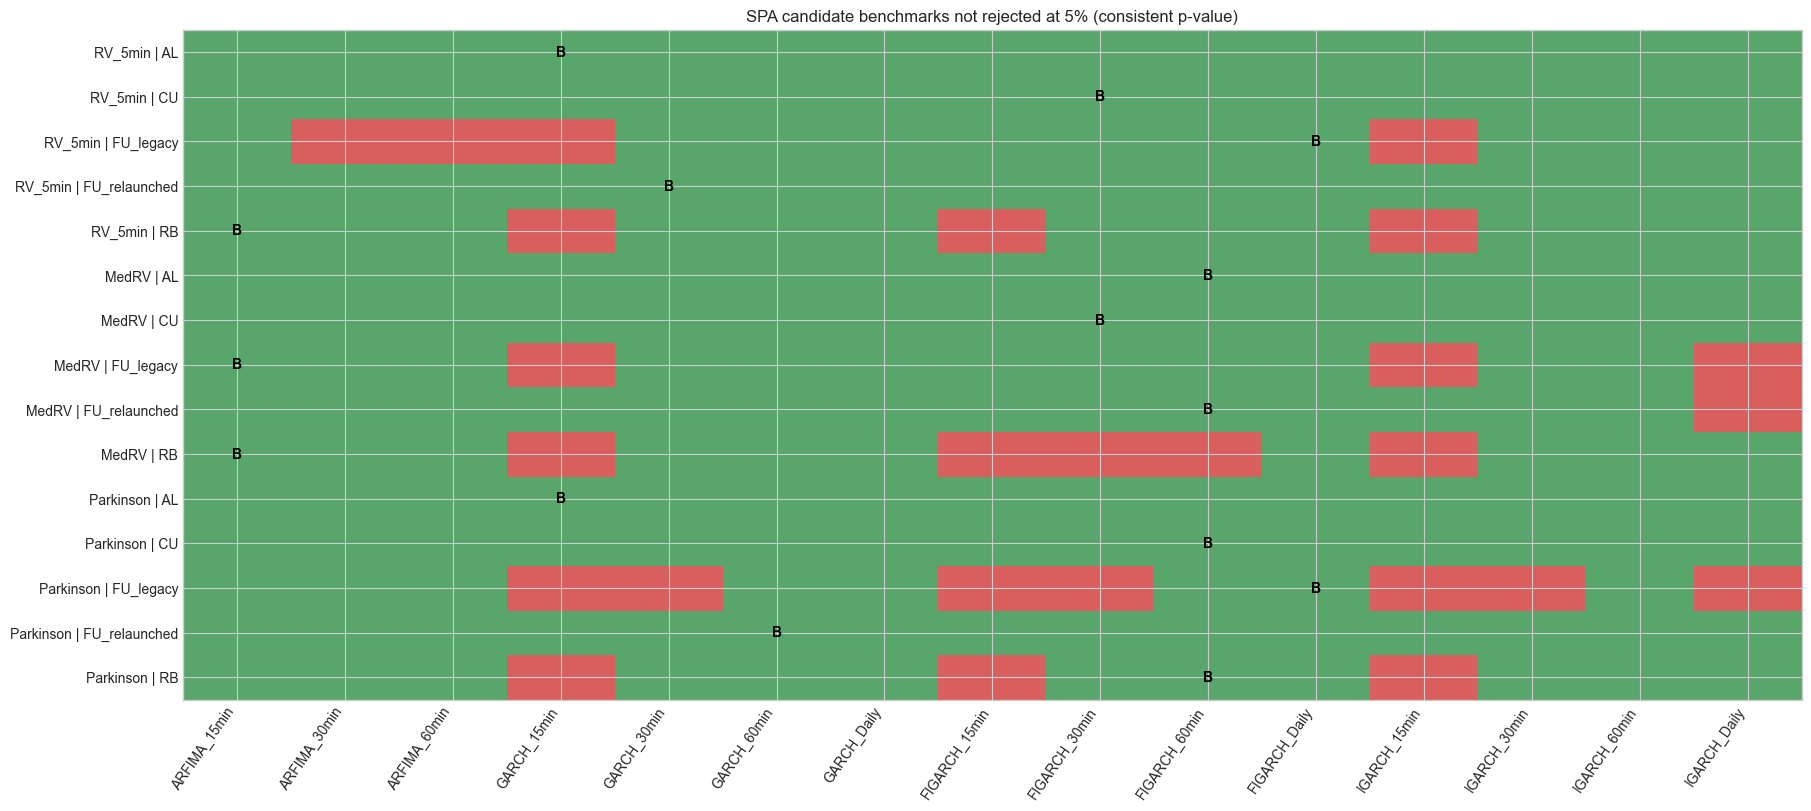

In [13]:
candidate_membership_df = candidate_catalog_df.pivot(
    index=["proxy_id", "series_id"],
    columns="candidate_model_id",
    values="spa_not_rejected_at_5pct",
)
ordered_group_index = pd.MultiIndex.from_tuples(
    [
        (proxy_id, series_id)
        for proxy_id in proxy_order
        for series_id in series_order
    ],
    names=["proxy_id", "series_id"],
)
candidate_membership_df = candidate_membership_df.reindex(
    index=ordered_group_index,
    columns=model_display_order,
)
best_model_by_group = {
    (row.proxy_id, row.series_id): row.lowest_rmsfe_model
    for row in group_spa_set_df.itertuples(index=False)
}

figure, axis = plt.subplots(figsize=(18, 8), constrained_layout=True)
membership_image = axis.imshow(
    candidate_membership_df.to_numpy(dtype=float),
    aspect="auto",
    cmap=plt.matplotlib.colors.ListedColormap(["#d95f5f", "#58a66b"]),
    vmin=0,
    vmax=1,
)
axis.set_xticks(
    np.arange(len(model_display_order)),
    labels=model_display_order,
    rotation=55,
    ha="right",
)
axis.set_yticks(
    np.arange(len(candidate_membership_df)),
    labels=[
        f"{proxy_id} | {series_id}"
        for proxy_id, series_id in candidate_membership_df.index
    ],
)
axis.set_title("SPA candidate benchmarks not rejected at 5% (consistent p-value)")
for row_index, group_key in enumerate(candidate_membership_df.index):
    best_model_id = best_model_by_group[group_key]
    best_column_index = model_display_order.index(best_model_id)
    axis.text(
        best_column_index,
        row_index,
        "B",
        ha="center",
        va="center",
        color="black",
        fontsize=10,
        fontweight="bold",
    )
plt.show()


## 13. 独立公式复核与验证门禁

门禁独立复核三层核心：①直接从固定种子生成初始随机起点与 uniform 序列，手工递推首条 stationary-bootstrap 索引；②对一个真实模型对逐滞后手工计算 Hansen 长期方差；③选择观察统计量最大的候选基准，直接从保存于内存的 bootstrap 模型均值重算 consistent 重心、10,000 个 studentized 最大统计量及 p 值。另验证 p 值顺序、离散分辨率、Table 9 与候选全集、FU/RB 边界和无敏感性流混入。


In [14]:
manual_index_checks = []
for observations in evaluation_lengths:
    block_size = int(np.floor(np.sqrt(observations)))
    manual_generator = np.random.default_rng(bootstrap_seed)
    random_start_indices = manual_generator.integers(
        0,
        observations,
        size=observations,
        dtype=np.int64,
    )
    continuation_uniforms = manual_generator.random(observations)
    manual_first_bootstrap_index = random_start_indices.copy()
    restart_probability = 1.0 / block_size
    for position in range(1, observations):
        if continuation_uniforms[position] > restart_probability:
            manual_first_bootstrap_index[position] = (
                manual_first_bootstrap_index[position - 1] + 1
            ) % observations
    manual_index_checks.append(
        np.array_equal(
            manual_first_bootstrap_index,
            bootstrap_indices_by_observations[observations][0],
        )
    )

small_indices_a = generate_stationary_bootstrap_indices(
    observations=12,
    block_size=3,
    replications=25,
    seed=bootstrap_seed,
)
small_indices_b = generate_stationary_bootstrap_indices(
    observations=12,
    block_size=3,
    replications=25,
    seed=bootstrap_seed,
)

variance_group_key = ("RV_5min", "AL")
variance_artifact = spa_group_artifact_by_key[variance_group_key]
variance_candidate_index = 0
variance_alternative_index = 1
manual_loss_differential = (
    variance_artifact["model_loss_matrix"][:, variance_candidate_index]
    - variance_artifact["model_loss_matrix"][:, variance_alternative_index]
)
manual_centered_differential = (
    manual_loss_differential - manual_loss_differential.mean()
)
manual_observations = len(manual_centered_differential)
manual_block_size = int(np.floor(np.sqrt(manual_observations)))
manual_continuation_probability = 1.0 - 1.0 / manual_block_size
manual_long_run_variance = float(
    np.dot(
        manual_centered_differential,
        manual_centered_differential,
    )
    / manual_observations
)
for lag in range(1, manual_observations):
    manual_kernel_weight = (
        (1.0 - lag / manual_observations)
        * manual_continuation_probability**lag
        + (lag / manual_observations)
        * manual_continuation_probability
        ** (manual_observations - lag)
    )
    manual_long_run_variance += float(
        2.0
        * manual_kernel_weight
        * np.dot(
            manual_centered_differential[:-lag],
            manual_centered_differential[lag:],
        )
        / manual_observations
    )
covariance_pair_variance = float(
    variance_artifact["pairwise_long_run_variance"][
        variance_candidate_index,
        variance_alternative_index,
    ]
)

manual_spa_row = spa_candidate_df.loc[
    spa_candidate_df["spa_test_statistic"].idxmax()
]
manual_spa_key = (manual_spa_row.proxy_id, manual_spa_row.series_id)
manual_spa_artifact = spa_group_artifact_by_key[manual_spa_key]
manual_candidate_index = manual_spa_artifact["model_ids"].index(
    manual_spa_row.candidate_model_id
)
manual_alternative_indices = np.array(
    [
        model_index
        for model_index in range(len(model_display_order))
        if model_index != manual_candidate_index
    ]
)
manual_differential_mean = (
    manual_spa_artifact["model_loss_means"][manual_candidate_index]
    - manual_spa_artifact["model_loss_means"][
        manual_alternative_indices
    ]
)
manual_differential_variance = manual_spa_artifact[
    "pairwise_long_run_variance"
][manual_candidate_index, manual_alternative_indices]
manual_differential_scale = np.sqrt(manual_differential_variance)
manual_square_root_observations = np.sqrt(manual_spa_row.observations)
manual_observed_components = (
    manual_square_root_observations
    * manual_differential_mean
    / manual_differential_scale
)
manual_spa_statistic = float(
    max(0.0, float(manual_observed_components.max()))
)
manual_consistency_threshold = -np.sqrt(
    manual_differential_variance
    / manual_spa_row.observations
    * 2.0
    * np.log(np.log(manual_spa_row.observations))
)
manual_consistent_center = np.where(
    manual_differential_mean >= manual_consistency_threshold,
    manual_differential_mean,
    0.0,
)
manual_bootstrap_differential_mean = (
    manual_spa_artifact["bootstrap_model_loss_means"][
        :, manual_candidate_index, None
    ]
    - manual_spa_artifact["bootstrap_model_loss_means"][
        :, manual_alternative_indices
    ]
)
manual_simulated_statistic = np.maximum(
    0.0,
    (
        manual_square_root_observations
        * (
            manual_bootstrap_differential_mean
            - manual_consistent_center
        )
        / manual_differential_scale
    ).max(axis=1),
)
manual_consistent_p_value = float(
    np.mean(manual_simulated_statistic > manual_spa_statistic)
)

validation_rows = []


def add_gate(gate, passed, evidence):
    validation_rows.append(
        {"gate": gate, "passed": bool(passed), "evidence": str(evidence)}
    )


add_gate(
    "latitude_environment",
    current_python == expected_python,
    current_python,
)
add_gate(
    "fixed_item09_identity_and_hashes",
    success_payload["manifest_sha256"] == sha256_file(manifest_path)
    and artifact_file_audit_df["integrity_passed"].all()
    and upstream_validation_df["passed"].all(),
    f"run_id={fixed_run_id}; files={len(artifact_file_audit_df)}; upstream_gates=27",
)
add_gate(
    "primary_forecast_grid_only",
    len(forecast_panel_df) == 31_200
    and len(primary_forecast_df) == 19_500
    and primary_forecast_df["model_id"].nunique() == 15
    and primary_forecast_df["is_primary"].all()
    and not primary_forecast_df["model_id"].str.contains(
        "no_lookahead", regex=False
    ).any(),
    "31,200 artifact rows loaded; SPA uses exactly 19,500 primary rows and 15 models",
)
add_gate(
    "forecast_grid_and_oos_counts",
    oos_date_audit_df.set_index("series_id")["oos_days"].to_dict()
    == {"AL": 300, "CU": 300, "FU_legacy": 200, "FU_relaunched": 200, "RB": 300},
    "AL/CU/RB=300; each FU segment=200",
)
add_gate(
    "model_information_precedes_target",
    primary_forecast_df["model_information_end"].lt(
        primary_forecast_df["forecast_date"]
    ).all(),
    "模型估计信息严格早于目标日；primary 全文季节因子的前视性质单独披露",
)
add_gate(
    "three_month_contract_and_session_structure",
    len(target_session_audit_df) == 1_300
    and target_session_audit_df["session_count"].eq(3).all()
    and target_session_audit_df["minute_count"].eq(225).all()
    and target_day_df["delivery_year"].eq(target_delivery_period.year).all()
    and target_day_df["delivery_month"].eq(target_delivery_period.month).all(),
    "1,300 target days; +3 delivery month; 3 day sessions; 225 minutes",
)
add_gate(
    "three_proxies_complete_nonnegative",
    len(volatility_proxy_df) == 1_300
    and all(
        np.isfinite(volatility_proxy_df[proxy_column]).all()
        and volatility_proxy_df[proxy_column].ge(0).all()
        for proxy_column, _, _ in proxy_spec
    ),
    "1,300 days × RV/MedRV/Parkinson; finite and nonnegative",
)
add_gate(
    "loss_and_rmsfe_grid_complete",
    len(primary_loss_df) == 58_500
    and len(primary_rmsfe_df) == 225
    and np.isfinite(primary_loss_df["squared_forecast_error"]).all()
    and np.isfinite(primary_rmsfe_df["rmsfe"]).all(),
    "58,500 primary losses; 225 primary RMSFE values",
)
add_gate(
    "bootstrap_configuration",
    bootstrap_replications == 10_000
    and bootstrap_seed == 20_260_830
    and bootstrap_index_audit_df.set_index("observations")[
        "block_size"
    ].to_dict()
    == {200: 14, 300: 17},
    "stationary; 10,000 reps; seed=20260830; blocks 14/17",
)
add_gate(
    "bootstrap_index_range_and_shape",
    all(
        bootstrap_indices_by_observations[observations].shape
        == (bootstrap_replications, observations)
        and bootstrap_indices_by_observations[observations].min() == 0
        and bootstrap_indices_by_observations[observations].max()
        == observations - 1
        for observations in evaluation_lengths
    ),
    "both fixed bootstrap index matrices cover valid [0, R-1] indices",
)
add_gate(
    "manual_first_stationary_path",
    all(manual_index_checks),
    "default_rng starts/uniforms reproduce the first R=200 and R=300 bootstrap paths",
)
add_gate(
    "small_seed_reproducibility",
    np.array_equal(small_indices_a, small_indices_b),
    "two independent 12-observation generators with seed 20260830 are identical",
)
add_gate(
    "manual_long_run_variance",
    np.isclose(
        manual_long_run_variance,
        covariance_pair_variance,
        rtol=1e-12,
        atol=0.0,
    ),
    f"manual={manual_long_run_variance:.12e}; matrix={covariance_pair_variance:.12e}",
)
add_gate(
    "candidate_spa_grid_complete",
    len(spa_candidate_df) == 225
    and spa_candidate_df.groupby(
        ["proxy_id", "series_id"], observed=True
    ).size().eq(15).all()
    and spa_candidate_df["alternative_models"].eq(14).all(),
    "15 groups × 15 candidate benchmarks; each tests 14 alternatives",
)
add_gate(
    "studentized_spa_outputs_finite",
    np.isfinite(
        spa_candidate_df[
            [
                "spa_test_statistic",
                "p_value_lower",
                "p_value_consistent",
                "p_value_upper",
                "critical_value_consistent_5pct",
            ]
        ]
    ).all().all()
    and spa_candidate_df["spa_test_statistic"].ge(0.0).all(),
    "225 finite studentized statistics, p-values and critical values",
)
add_gate(
    "spa_pvalue_order_and_resolution",
    spa_candidate_df["p_value_lower"].le(
        spa_candidate_df["p_value_consistent"] + 1e-15
    ).all()
    and spa_candidate_df["p_value_consistent"].le(
        spa_candidate_df["p_value_upper"] + 1e-15
    ).all()
    and all(
        np.allclose(
            spa_candidate_df[p_value_column] * bootstrap_replications,
            np.round(
                spa_candidate_df[p_value_column]
                * bootstrap_replications
            ),
            rtol=0.0,
            atol=1e-10,
        )
        for p_value_column in [
            "p_value_lower",
            "p_value_consistent",
            "p_value_upper",
        ]
    ),
    "lower <= consistent <= upper; empirical p-value step is 1/10,000",
)
add_gate(
    "manual_consistent_spa_pvalue",
    np.isclose(
        manual_spa_statistic,
        manual_spa_row.spa_test_statistic,
        rtol=1e-13,
        atol=0.0,
    )
    and np.isclose(
        manual_consistent_p_value,
        manual_spa_row.p_value_consistent,
        rtol=0.0,
        atol=0.0,
    ),
    f"manual statistic={manual_spa_statistic:.8f}; p={manual_consistent_p_value:.4f}",
)
add_gate(
    "table9_lowest_rmsfe_benchmarks",
    len(spa_table9_df) == 15
    and spa_table9_df["spa_test_statistic"].eq(0.0).all()
    and spa_table9_df[
        ["p_value_lower", "p_value_consistent", "p_value_upper"]
    ].eq(1.0).all().all(),
    "each sample-minimum RMSFE benchmark has nonpositive mean differentials, T=0 and p=1",
)
add_gate(
    "lowest_rmsfe_in_not_rejected_set",
    candidate_catalog_df.loc[
        candidate_catalog_df["is_lowest_rmsfe"],
        "spa_not_rejected_at_5pct",
    ].all()
    and group_spa_set_df["not_rejected_model_count"].between(1, 15).all(),
    "all 15 sample-best models are retained; every group has a nonempty candidate set",
)
add_gate(
    "candidate_classification_complete",
    model_class_synthesis_df["candidate_opportunities"].sum() == 225
    and frequency_synthesis_df["candidate_opportunities"].sum() == 225
    and daily_intraday_synthesis_df["candidate_opportunities"].sum() == 225,
    "model class, interval and daily/intraday summaries each cover all 225 candidates",
)
add_gate(
    "fu_segments_and_rb_separate",
    target_day_df.loc[
        target_day_df["series_id"].eq("FU_legacy"), "forecast_date"
    ].max()
    == pd.Timestamp("2011-09-30")
    and target_day_df.loc[
        target_day_df["series_id"].eq("FU_relaunched"), "forecast_date"
    ].min()
    > pd.Timestamp("2020-01-02")
    and group_spa_set_df.loc[
        group_spa_set_df["series_id"].eq("RB")
    ].shape[0]
    == 3,
    "FU two regimes are not connected; RB has three independent proxy groups",
)

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
assert validation_df["passed"].all(), validation_df.loc[
    ~validation_df["passed"]
]
print(f"全部 {len(validation_df)} 项门禁通过。")


,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,fixed_item09_identity_and_hashes,True,run_id=eaf4757d3488c2b7; files=4; upstream_gates=27
2,primary_forecast_grid_only,True,"31,200 artifact rows loaded; SPA uses exactly 19,500 primary rows and 15 models"
3,forecast_grid_and_oos_counts,True,AL/CU/RB=300; each FU segment=200
4,model_information_precedes_target,True,模型估计信息严格早于目标日；primary 全文季节因子的前视性质单独披露
5,three_month_contract_and_session_structure,True,"1,300 target days; +3 delivery month; 3 day sessions; 225 minutes"
6,three_proxies_complete_nonnegative,True,"1,300 days × RV/MedRV/Parkinson; finite and nonnegative"
7,loss_and_rmsfe_grid_complete,True,"58,500 primary losses; 225 primary RMSFE values"
8,bootstrap_configuration,True,"stationary; 10,000 reps; seed=20260830; blocks 14/17"
9,bootstrap_index_range_and_shape,True,"both fixed bootstrap index matrices cover valid [0, R-1] indices"


全部 21 项门禁通过。


## 14. 最终模型综合、解释与限制

最低 RMSFE 是样本排序；Table 9 SPA 判断这一基准是否被整个竞争集合推翻；轮流候选检验则显示哪些模型尚不能在 5% 水平判为劣势。下面把三层信息按模型类别和采样频率归纳，但不把“未拒绝”误写为统计等价。


In [15]:
table9_rejections = int(spa_table9_df["spa_rejected_at_5pct"].sum())
total_not_rejected_candidates = int(
    candidate_catalog_df["spa_not_rejected_at_5pct"].sum()
)
smallest_candidate_set_row = group_spa_set_df.loc[
    group_spa_set_df["not_rejected_model_count"].idxmin()
]
largest_candidate_set_row = group_spa_set_df.loc[
    group_spa_set_df["not_rejected_model_count"].idxmax()
]
daily_summary_row = daily_intraday_synthesis_df.loc[
    daily_intraday_synthesis_df["sampling_scope"].eq("Daily")
].iloc[0]
intraday_summary_row = daily_intraday_synthesis_df.loc[
    daily_intraday_synthesis_df["sampling_scope"].eq("Intraday")
].iloc[0]
highest_non_rejected_class_row = model_class_synthesis_df.loc[
    model_class_synthesis_df["spa_not_rejected_rate"].idxmax()
]
highest_non_rejected_frequency_row = frequency_synthesis_df.loc[
    frequency_synthesis_df["spa_not_rejected_rate"].idxmax()
]

display(
    Markdown(
        f'''**Table 9 风格结论。** 15 个最低 RMSFE 基准中有 {table9_rejections} 个在 5% consistent SPA 水平被拒绝。由于每个基准本身就是同一评价样本的最小平均平方损失，全部损失差均值不为正，studentized 观察统计量按零下限等于 0；依 Hansen 约定三种 p 值均为 1。这说明 Table 9 的“未拒绝”主要确认没有模型在样本均值上超过已选第一名，不能单独证明第一名显著优于其余模型。'''
    )
)
display(
    Markdown(
        f'''**候选集合。** 225 个轮流候选基准中共有 {total_not_rejected_candidates} 个在 5% consistent SPA 下未被拒绝。集合最小的是 `{smallest_candidate_set_row['proxy_id']} / {smallest_candidate_set_row['series_id']}`，保留 {smallest_candidate_set_row['not_rejected_model_count']} 个模型；最大的是 `{largest_candidate_set_row['proxy_id']} / {largest_candidate_set_row['series_id']}`，保留 {largest_candidate_set_row['not_rejected_model_count']} 个。未拒绝率最高的模型类别是 `{highest_non_rejected_class_row['model_label']}`（{highest_non_rejected_class_row['spa_not_rejected_rate']:.2%}），最高的采样频率是 `{highest_non_rejected_frequency_row['interval_label']}`（{highest_non_rejected_frequency_row['spa_not_rejected_rate']:.2%}）。'''
    )
)
display(
    Markdown(
        f'''**日频与盘中。** 日频模型在 {int(daily_summary_row.candidate_opportunities)} 次候选机会中取得 {int(daily_summary_row.lowest_rmsfe_count)} 次最低 RMSFE、{int(daily_summary_row.spa_not_rejected_count)} 次未拒绝；盘中模型在 {int(intraday_summary_row.candidate_opportunities)} 次机会中分别为 {int(intraday_summary_row.lowest_rmsfe_count)} 和 {int(intraday_summary_row.spa_not_rejected_count)} 次。应比较比例而不是原始次数，因为盘中候选数量是日频的四倍。RB 的三组结果保持单列，不能用其表现替代论文品种结论。'''
    )
)
display(
    Markdown(
        '''**限制。** SPA 仍以 RV、MedRV 或 Parkinson 代理为真值，平方损失对极端日敏感。论文 primary 季节因子使用全文样本，含明确前视信息；为保持论文基线，本项只检验 15 个 primary 模型，第 10 项的不稳定无前视敏感性流被排除。`block_size=floor(sqrt(R))`、固定种子、共同随机数和不使用嵌套 bootstrap 是论文未披露的项目口径。轮流候选检验对每个候选内部控制 14 个竞争模型，但 15 次候选检验的并集不是正式模型置信集合，因此只能写成“未拒绝候选”，不能宣称模型统计等价。所有结论只适用于当前 JQData 真实日盘、固定三个月交割合约和 FU 分段样本。'''
    )
)


**Table 9 风格结论。** 15 个最低 RMSFE 基准中有 0 个在 5% consistent SPA 水平被拒绝。由于每个基准本身就是同一评价样本的最小平均平方损失，全部损失差均值不为正，studentized 观察统计量按零下限等于 0；依 Hansen 约定三种 p 值均为 1。这说明 Table 9 的“未拒绝”主要确认没有模型在样本均值上超过已选第一名，不能单独证明第一名显著优于其余模型。

**候选集合。** 225 个轮流候选基准中共有 199 个在 5% consistent SPA 下未被拒绝。集合最小的是 `Parkinson / FU_legacy`，保留 8 个模型；最大的是 `RV_5min / AL`，保留 15 个。未拒绝率最高的模型类别是 `ARFIMA`（95.56%），最高的采样频率是 `60-min`（96.67%）。

**日频与盘中。** 日频模型在 45 次候选机会中取得 2 次最低 RMSFE、42 次未拒绝；盘中模型在 180 次机会中分别为 13 和 157 次。应比较比例而不是原始次数，因为盘中候选数量是日频的四倍。RB 的三组结果保持单列，不能用其表现替代论文品种结论。

**限制。** SPA 仍以 RV、MedRV 或 Parkinson 代理为真值，平方损失对极端日敏感。论文 primary 季节因子使用全文样本，含明确前视信息；为保持论文基线，本项只检验 15 个 primary 模型，第 10 项的不稳定无前视敏感性流被排除。`block_size=floor(sqrt(R))`、固定种子、共同随机数和不使用嵌套 bootstrap 是论文未披露的项目口径。轮流候选检验对每个候选内部控制 14 个竞争模型，但 15 次候选检验的并集不是正式模型置信集合，因此只能写成“未拒绝候选”，不能宣称模型统计等价。所有结论只适用于当前 JQData 真实日盘、固定三个月交割合约和 FU 分段样本。